# Laboratorio – Sesión 3
## Análisis Exploratorio del World Happiness Report 2015–2024
Versión Formativa


### Instrucciones
Siga cada reto, complete el código y las interpretaciones.

## RETO 1 – Estadística descriptiva

In [22]:
# =========================
# 0.1 Importar librerías
# =========================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.precision", 3)

In [7]:
# Cargue y unifique aquí

years = range(2015, 2025)  # 2015 a 2024
dfs = []

for year in years:
    file_name = f"./data/world_happiness_{year}.csv" 

    df_year = pd.read_csv(
        file_name,
        sep=";",              # Los archivos usan ';' como separador
        engine="python",      # Motor más flexible
        on_bad_lines="skip"    # Ignora filas defectuosas para evitar errores
    )

    df_year["Year"] = year
    dfs.append(df_year)


df = pd.concat(dfs, ignore_index=True)

df.head(10)

,Ranking,Country,Regional indicator,Happiness score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,Year,Ladder score
0,1,Switzerland,Western Europe,"7,59","8,26","0,96",73.0,"0,99","0,37","0,24",2015,NaN
1,2,Iceland,Western Europe,"7,56","7,7",1,73.0,"0,94","0,55","0,74",2015,NaN
2,3,Denmark,Western Europe,"7,53","7,84","0,97",70.0,"0,97","0,43","0,12",2015,NaN
3,4,Norway,Western Europe,"7,52","8,63","0,95",71.0,1,"0,44","0,34",2015,NaN
4,5,Canada,North America and ANZ,"7,43","7,85","0,94",71.0,"0,95","0,58","0,4",2015,NaN
5,6,Finland,Western Europe,"7,41","7,63","0,94",71.0,"0,96","0,29","0,25",2015,NaN
6,7,Netherlands,Western Europe,"7,38","7,86","0,91",71.0,"0,92","0,6","0,42",2015,NaN
7,8,Sweden,Western Europe,"7,36","7,88","0,92",72.0,"0,99","0,46","0,21",2015,NaN
8,9,New Zealand,North America and ANZ,"7,29","7,4","0,94",72.0,"0,95","0,6","0,22",2015,NaN
9,10,Australia,North America and ANZ,"7,28","7,89","0,93",72.0,"0,97","0,55","0,35",2015,NaN


In [8]:
# =========================
# Crear columna numérica de felicidad y renombrar columnas
# =========================

df["Happiness_score_num"] = (
    df["Happiness score"].astype(str).str.replace(",", ".", regex=False)
)
df["Happiness_score_num"] = pd.to_numeric(df["Happiness_score_num"], errors="coerce")

df = df.rename(columns={
    "Regional indicator": "Region",
    "GDP per capita": "GDP_per_capita",
    "Social support": "Social_support",
    "Healthy life expectancy": "Healthy_life_expectancy",
    "Freedom to make life choices": "Freedom",
    "Perceptions of corruption": "Corruption",
})

df.head()

,Ranking,Country,Region,Happiness score,GDP_per_capita,Social_support,Healthy_life_expectancy,Freedom,Generosity,Corruption,Year,Ladder score,Happiness_score_num
0,1,Switzerland,Western Europe,"7,59","8,26","0,96",73.0,"0,99","0,37","0,24",2015,NaN,7.59
1,2,Iceland,Western Europe,"7,56","7,7",1,73.0,"0,94","0,55","0,74",2015,NaN,7.56
2,3,Denmark,Western Europe,"7,53","7,84","0,97",70.0,"0,97","0,43","0,12",2015,NaN,7.53
3,4,Norway,Western Europe,"7,52","8,63","0,95",71.0,1,"0,44","0,34",2015,NaN,7.52
4,5,Canada,North America and ANZ,"7,43","7,85","0,94",71.0,"0,95","0,58","0,4",2015,NaN,7.43


Responda las preguntas aquí.

## RETO 2 – Categorización

In [ ]:
region_summary = df.groupby("Region")["Happiness_score_num"].agg(["count", "mean", "median", "std"]).sort_values("mean", ascending=False)
region_summary

,count,mean,median,std
Region,,,,
North America and ANZ,36,7.176,7.225,0.157
Western Europe,209,6.710,6.891,0.767
Latin America and Caribbean,190,5.994,6.096,0.654
Central and Eastern Europe,127,5.712,5.758,0.586
East Asia,61,5.676,5.761,0.502
Southeast Asia,74,5.385,5.357,0.728
Commonwealth of Independent States,95,5.352,5.399,0.553
Middle East and North Africa,173,5.254,5.132,1.032
South Asia,59,4.449,4.510,0.809


In [12]:
df['Happiness_score_num'].describe()

count    1362.000
mean        5.440
std         1.120
min         1.859
25%         4.593
50%         5.430
75%         6.258
max         7.842
Name: Happiness_score_num, dtype: float64

### Criterio utilizado

Sabemos que la felicidad mínima observada está cerca de **1.86** y la máxima en torno a **7.84**. Además, los cuartiles son aproximadamente:
- Q1 ≈ **4.59**
- Q2 (mediana) ≈ **5.43**
- Q3 ≈ **6.26**

Para simplificar en clase, definiremos los niveles así:

- **Low**: `Happiness_score_num < 4.5`
- **Medium**: `4.5 <= Happiness_score_num <= 6.5`
- **High**: `Happiness_score_num > 6.5

In [14]:
# =========================
# Variable categórica de nivel de felicidad
# =========================

bins = [0, 4.5, 6.5, 11]
labels = ["Low", "Medium", "High"]

df["Happiness_level"] = pd.cut(
    df["Happiness_score_num"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

df[["Country", "Year", "Happiness_score_num", "Happiness_level"]].head(10)

,Country,Year,Happiness_score_num,Happiness_level
0,Switzerland,2015,7.59,High
1,Iceland,2015,7.56,High
2,Denmark,2015,7.53,High
3,Norway,2015,7.52,High
4,Canada,2015,7.43,High
5,Finland,2015,7.41,High
6,Netherlands,2015,7.38,High
7,Sweden,2015,7.36,High
8,New Zealand,2015,7.29,High
9,Australia,2015,7.28,High


In [17]:
df.isna().sum()

Ranking                       0
Country                       0
Region                        3
Happiness score             140
GDP_per_capita                0
Social_support                0
Healthy_life_expectancy       1
Freedom                       0
Generosity                    0
Corruption                    0
Year                          0
Ladder score               1362
Happiness_score_num         140
Happiness_level             140
dtype: int64

In [18]:
# Porcentajes

level_perc = df["Happiness_level"].value_counts(normalize=True, dropna=True) * 100

level_perc

Happiness_level
Medium    61.013
Low       21.806
High      17.181
Name: proportion, dtype: float64

Analice porcentajes y regiones.

## RETO 3 – Gráficos

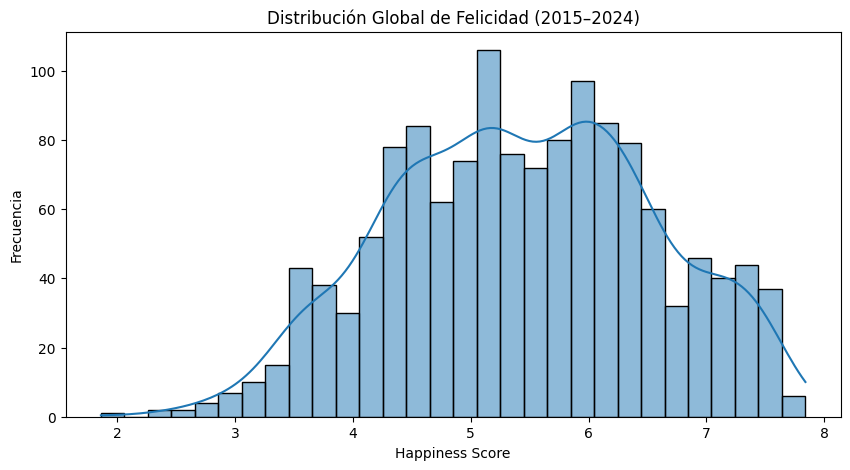

In [23]:
# Histograma
plt.figure(figsize=(10,5))
sns.histplot(df['Happiness_score_num'],bins=30,kde=True)
plt.title('Distribución Global de Felicidad (2015–2024)')
plt.xlabel('Happiness Score')
plt.ylabel('Frecuencia')
plt.show()

In [ ]:
# Boxplot

In [ ]:
# Línea temporal

In [ ]:
# Gráfico adicional

## RETO 4 – Outliers

In [ ]:
# IQR

In [ ]:
# Z-score

Conclusiones finales.